In [1]:
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv())

import warnings

warnings.filterwarnings("ignore")
import kairo


In [2]:
log = kairo.read_log("../data/reassignment.xes")
log = kairo.map_columns(log, {
    "case ID": "case:concept:name", "activity": "concept:name",
    "timestamp": "time:timestamp", "resource": "org:resource",
    "event duration": "event:duration_min",
})


parsing log, completed traces :: 100%|██████████████████████████████████████████████████████████████████████████████████| 9967/9967 [00:00<00:00, 12292.27it/s]


In [3]:
stats = kairo.log_statistics(log)
print(kairo.abstract_log_statistics(stats))


Event log statistics:
cases: 9967, events: 65067, activities: 7, resources: 7
time span: 2020-01-01 01:00:37.100019+00:00 → 2020-12-31 11:50:19.913963+00:00 (526250 minutes)
throughput time (days): min 0.00, mean 0.18, median 0.13, max 2.24
case length (events): min 1, mean 6.5, median 6.0, max 67
activity frequencies: a (19983), b (10016), f (10016), g (10016), d (5020), e (5020), c (4996)
resource frequencies: res_05 (17882), res_07 (13755), res_04 (11886), res_06 (8140), res_03 (5860), res_01 (5706), res_02 (1838)


In [5]:
print(stats.resource_counts)

org:resource
res_05    17882
res_07    13755
res_04    11886
res_06     8140
res_03     5860
res_01     5706
res_02     1838
Name: count, dtype: int64


A resource state is one **calendar window**, not one event: each row describes how the whole
pool behaved in that window.


In [6]:
config = kairo.ResourceConfig(
    features=("events", "active", "duration", "wait", "activity_events", "ho"),
    window_minutes=1440 * 15,                 # one state per day
    clustering="som", grid=(3, 3), metric="euclidean",
    pca_components=10,
    signal_metric="euclidean",           # windows are vectors, so distance, not divergence
    signal_reference="recent", signal_lookback=3,
)

result = kairo.run_resource(log, config)
result.to_dict()


{'perspective': 'resource',
 'config': {'features': ('events',
   'active',
   'duration',
   'wait',
   'activity_events',
   'ho'),
  'resources': (),
  'activities': (),
  'window_minutes': 21600,
  'skip_pca': False,
  'pca_components': 10,
  'scaling': 'none',
  'clustering': 'som',
  'metric': 'euclidean',
  'grid': (3, 3),
  'som_init': 'random',
  'n_clusters': 6,
  'eps': 0.5,
  'min_samples': 5,
  'signal_metric': 'euclidean',
  'signal_reference': 'recent',
  'signal_lookback': 3,
  'seed': 7},
 'rows': 25,
 'feature_columns': 119,
 'pca_components': 10,
 'n_states': 9,
 'method': 'som',
 'transitions': 16,
 'windows': 25}

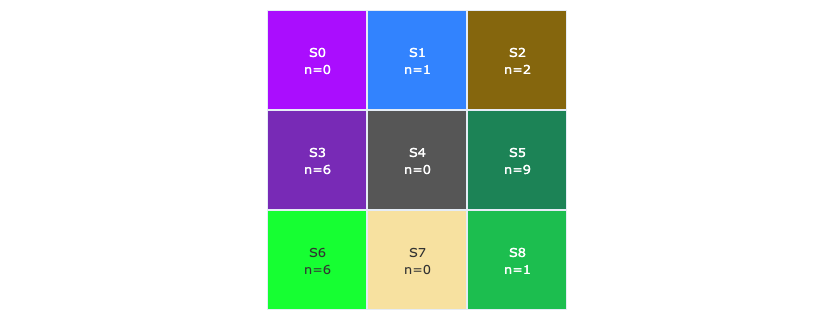

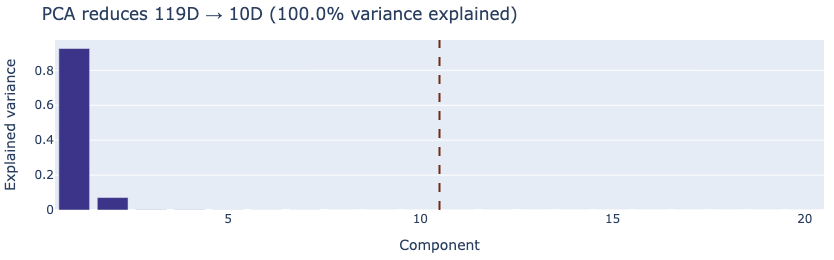

In [18]:
kairo.plot_state_grid(result.states).show()
kairo.plot_pca_variance(result.pca).show()


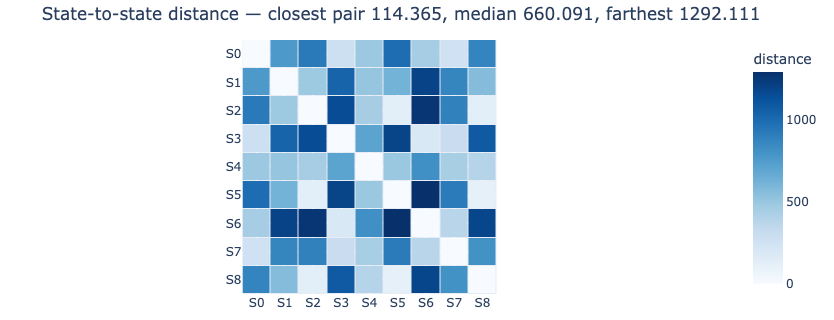

In [19]:
# how far apart the states sit — SOM only, it has a codebook
kairo.plot_state_distances(result.states, config.metric).show()


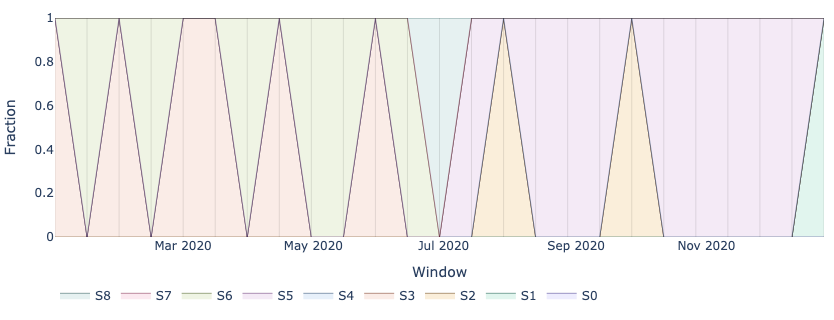

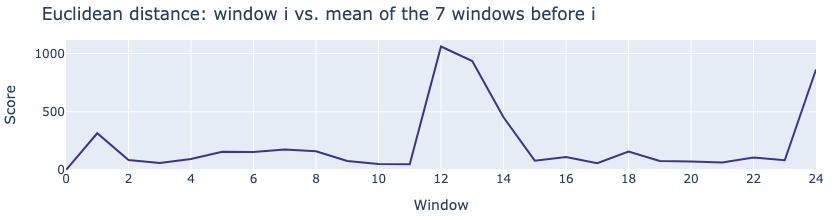

In [20]:
dist_fig = kairo.plot_state_distribution(result.distribution, result.states)
kairo.add_window_boundaries(dist_fig, result.distribution["window_start"])
dist_fig.show()

signal_fig = kairo.plot_drift_signal(
    result.signal, title="Euclidean distance: window i vs. mean of the 7 windows before i")
signal_fig.show()   # the three injected drifts should stand out


One global trajectory here — the whole pool moves through states together, so there is no
per-case view to pick from.


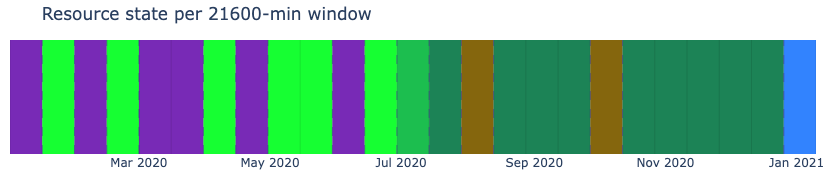

In [21]:
traj = result.trajectories
fig = kairo.plot_trajectory(
    traj["window_start"], traj["state_id"].to_numpy(), result.states,
    title=f"Resource state per {config.window_minutes}-min window", window_ticks=True)
kairo.add_transition_markers(fig, result.transitions["timestamp"])
fig.show()


In [22]:
# where the signal actually peaks, against the known drift points
kairo.analysis.top_drift_windows(result.signal, k=6)


,window_start,score
0,2020-06-29 01:00:37.100019,1060.425513
1,2020-07-14 01:00:37.100019,934.916646
2,2020-12-26 01:00:37.100019,863.072122
3,2020-07-29 01:00:37.100019,452.936176
4,2020-01-16 01:00:37.100019,315.256002
5,2020-04-15 01:00:37.100019,175.755788


In [23]:
profiles = kairo.analysis.state_profiles(result.features, result.states)
print(kairo.abstract_states(result.states, profiles=profiles, max_len=1500))


States from som (3×3 grid), parameters {'grid': (3, 3), 'metric': 'euclidean', 'init': 'random', 'epochs': 5, 'seed': 7}:
- S0: 0 samples (0.0%)
- S1: 1 samples (4.0%)
- S2: 2 samples (8.0%)
- S3: 6 samples (24.0%)
- S4: 0 samples (0.0%)
- S5: 9 samples (36.0%)
- S6: 6 samples (24.0%)
- S7: 0 samples (0.0%)
- S8: 1 samples (4.0%)
Distinguishing features per state (deviation from the overall mean, in stds):
  S1: active:res_02 (-3.5σ), activity_events:c:res_03 (+3.4σ), events:res_02 (-3.2σ), active:res_04 (-3.0σ), events:res_04 (-2.6σ)
  S2: activity_events:e:res_02 (+1.9σ), activity_events:g:res_07 (-1.7σ), activity_events:b:res_07 (+1.7σ), activity_events:e:res_07 (-1.6σ), ho:res_02→res_05 (-1.3σ)
  S3: ho:res_03→res_07 (+1.3σ), ho:res_01→res_06 (+1.2σ), ho:res_03→res_06 (+1.1σ), ho:res_03→res_04 (+1.1σ), ho:res_01→res_05 (+1.1σ)
  S5: events:res_03 (+1.1σ), events:res_01 (+1.1σ), events:res_07 (+1.1σ), active:res_03 (+1.1σ), active:res_07 (+1.1σ)
  S6: ho:res_03→res_05 (+1.3σ), event

In [24]:
print(kairo.abstract_result(result))


=== resource pipeline run ===

ResourceConfig parameters:
- features: ('events', 'active', 'duration', 'wait', 'activity_events', 'ho')
- resources: ()
- activities: ()
- window_minutes: 21600
- skip_pca: False
- pca_components: 10
- scaling: none
- clustering: som
- metric: euclidean
- grid: (3, 3)
- som_init: random
- n_clusters: 6
- eps: 0.5
- min_samples: 5
- signal_metric: euclidean
- signal_reference: recent
- signal_lookback: 3
- seed: 7

resource feature matrix: 25 rows × 119 columns.
- events (Events per resource): 7 columns
- active (Active cases per resource): 7 columns
- duration (Mean event duration per resource): 7 columns
- wait (Mean wait into resource): 7 columns
- activity_events (Activity-resource event shares): 49 columns
- ho (Handover shares): 42 columns
Column ranges (min → max, mean):
  events:res_01: 58.000 → 448.000, mean 228.240
  events:res_02: 27.000 → 100.000, mean 73.520
  events:res_03: 57.000 → 433.000, mean 234.400
  events:res_04: 146.000 → 694.000, m

### Narrowing the pool

`resources` and `activities` restrict which columns are produced. Share features keep
log-wide denominators, so a handover share still means the same thing.


In [ ]:
focused = kairo.run_resource(log, kairo.ResourceConfig(
    features=("events", "duration", "ho"),
    resources=("res_01", "res_02"),      # the two the duration drift slowed down
    window_minutes=1440, clustering="kmeans", n_clusters=4,
))
print(focused.features.matrix.shape, focused.features.columns)
kairo.plot_drift_signal(focused.signal, title="res_01 + res_02 only").show()


### Asking a model


In [ ]:
# Inspect the prompt without any network call
prompt = kairo.build_prompt("Which resources changed behaviour, and when?",
                            result=result, log=log)
print(prompt)


In [31]:
QUESTION = ("You have the details of the resource perspective analysis with the given config. What other parameters would you also use for a new config to get good insights?")


In [ ]:
# Local models
print(kairo.llm.available_models("local"))


In [ ]:
answer = kairo.ask(QUESTION, result=result, log=log, executor=kairo.local_query)
print(answer)


### Hosted providers


In [32]:
answer = kairo.ask(QUESTION, result=result, log=log,
                   executor=kairo.anthropic_query, model="claude-sonnet-5")
print(answer)


## Reading the diagnostics first

A few things in this run point to concrete parameter problems, not just "more analysis":

**1. PCA is telling you the space is basically 1‑D–2‑D, but you forced 10 components.**
PC1 alone explains 92.5% and PC2 another 7.1% — together 99.6%. PC3‑PC10 add essentially nothing (0.000‑0.001 each). Yet `pca_components=10` was fixed, so 8 useless components are being carried into clustering, diluting distances with noise. The elbow is clearly at 2.

**2. No scaling, and PC1/PC2 loadings are dominated by raw `events:res_*` counts (58‑1222 range).**
The `activity_events` and `ho` columns are shares in [0,1], so on raw scale they can never compete with resources doing hundreds/thousands of events. This is why every distinguishing-feature list for the SOM states is dominated by `events:` and `ho:` magnitude features rather than by behavioural mix — you're effectively clustering on total workload only.

**3. The 3×3 SOM is oversized for 25 samples.**
Three of nin

In [ ]:
# Explain a plot
explanation = kairo.explain_plot(
    signal_fig, "What does this drift signal show? Where would you place the drifts?",
    result=result, executor=kairo.anthropic_query, model="claude-sonnet-5")
print(explanation)


In [ ]:
cfg = kairo.nlp_to_config(
    "weekly windows, k-means with 6 clusters, compare each window against the full-log baseline",
    perspective="resource", executor=kairo.anthropic_query,
)
print(cfg)
kairo.run_resource(log, cfg)  # …and run it
